In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgbm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, 
                             roc_auc_score, confusion_matrix, 
                             ConfusionMatrixDisplay, 
                             roc_curve, 
                             accuracy_score
                             )

In [52]:
# upload cleaned csv file from previous data selection and understanding
df = pd.read_csv("../data/ai4i2020_v2.csv")

In [53]:
# Drop unnecessary column
df = df.drop(columns=['Unnamed: 0'])

In [54]:
df.columns

Index(['Type', 'Air Temperature', 'Process Temperature', 'Rotational Speed',
       'Torque', 'Tool Wear', 'Machine Failure'],
      dtype='object')

In [55]:
# Check for data types
df.dtypes

Type                    object
Air Temperature        float64
Process Temperature    float64
Rotational Speed         int64
Torque                 float64
Tool Wear                int64
Machine Failure          int64
dtype: object

From checking the datatypes:
- Type variable is object type.
- Therefore need to convert to numeric category

In [56]:
# Choose all the rows and columns except the last column, to target input. Uppercase X means a matrix
X = df.iloc[:, :-1]

# Choose the last column as target output. Lowercase y means its a vector
y = df['Machine Failure']

In [57]:
# Encode Categorical Data
X['Type'] = X['Type'].astype('category')

In [58]:
# Train-Test Split
# stratify=y used to reduce sample imbalance. So that the model notices adequate machine breakdown patterns.
# It changes from random suffling to grouped sampling process.
# To make the algorithm look at the target column, y. Then seperates the data into 2 buckets based on 0 and 1.
# Split the bucket by 80/20 ratio. 
# Bucket '0', 80% training 20% testing. Bucket '1', 80% training 20% testing.
# Lastly merge the bucket respectively back together and suffling them all.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [59]:
# Handle the Class Imbalance
# Purpose: To calculate the scalling factor, therefore missing the failure can be penalized.
# Allow the model to learn better by penalizing missing on failure.
# Inside the LightBGM model, there's scale_post_weight. When the data below passed into the model.
# ... it acts as a penalty multiplyer, everytime the model misclassifies a normal machine 0, it gets x amount penalty.
# ... if the model misses an actual machine failure, 1, it gets 'scale_norm_fail*x' penalty.
num_normal = np.sum(y_train == 0) # counts how many normal
num_failure = np.sum(y_train == 1) # counts how many failure
scale_norm_fail = num_normal/num_failure 
print('number of normal: ', num_normal)
print('number of failure: ', num_failure)
print('Scale: ', scale_norm_fail)

number of normal:  7729
number of failure:  271
Scale:  28.52029520295203


In [60]:
# Configure and Train LightBGM Classifier
model = lgbm.LGBMClassifier(
    objective = 'binary', # 2 output, 0: Machine Ok, 1: Machine Failure.
    boosting_type = 'gbdt', # The model learns from its previous mistake continuously.
    scale_pos_weight = scale_norm_fail, # Make the learn learns from its mistake for scale_norm_fail times.
    learning_rate = 0.05, # The model takes a smaller step (0.05) for training, longer to train, but will produced better result.
    num_leaves = 31, # Checklist/Trees of 'Yes' and 'No' of the models.
    random_state = 42, # Prevents the model random luck by training it consistency.
    n_estimators = 150, # Number of estimators evailable. 150 estimator will check mistake of 1 estimator.
    verbosity = -1 # Reduce noise by stopping the python to produce to many unnecessary warnin messages.
)

In [61]:
model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,150
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
# Evaluate Performance
y_predict = model.predict(X_test)

# Feed features in to the model by reading all the inputs (Temperature, Speed, Torque, and Type)
# Output will only have many rows of machines and 2 columns which is Chances of 0: Machine Healthy, 1: Machine Failure
# The result enable 1 format single column to be feed into ROC-AUC Score
y_predict_probability = model.predict_proba(X_test)[:, 1] 

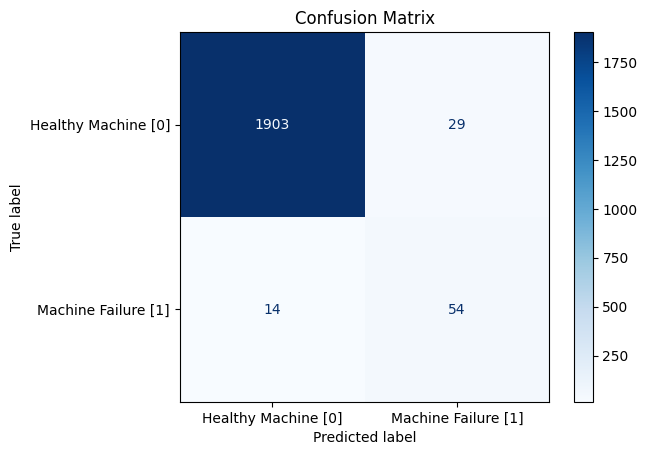

In [124]:
# Shows Confusion Matrix Display
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_predict, 
    display_labels=["Healthy Machine [0]", "Machine Failure [1]"], # Label 0: "Healthy Machine", 1: "Machine Failed"
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

In [123]:
report = classification_report(
    y_test,
    y_predict,
    target_names=["Healthy Machine [0]", "Machine Failure [1]"]
)

print("\t\tCLASSIFICATION REPORT:\n")
print(report)

		CLASSIFICATION REPORT:

                     precision    recall  f1-score   support

Healthy Machine [0]       0.99      0.98      0.99      1932
Machine Failure [1]       0.65      0.79      0.72        68

           accuracy                           0.98      2000
          macro avg       0.82      0.89      0.85      2000
       weighted avg       0.98      0.98      0.98      2000



Text(0, 0.5, 'True Positive Rate')

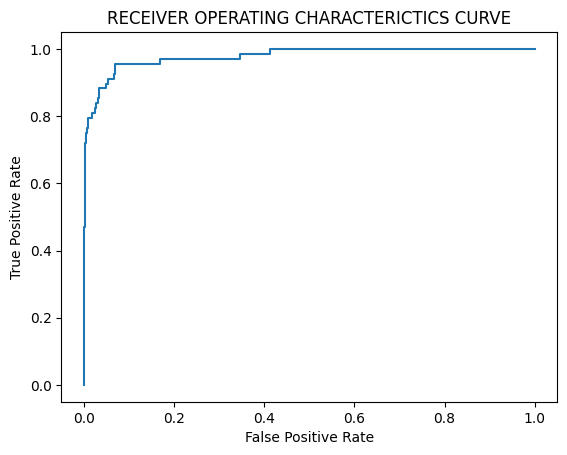

In [114]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probability)
plt.plot(fpr, tpr)
plt.title("RECEIVER OPERATING CHARACTERICTICS CURVE")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

In [94]:
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_probability):.2f}")

ROC-AUC Score: 0.98


DISCUSSION:
1. CONFUSION MATRIX:
   - From the visualization result. Ono the Predicted Positive, the model able to correctly identify 1903 True Positive (TP) and 29 False Positive (FP). On the predicted negative, 14 are predicted False Negative (FP), and 54 predicted True Negative (TN).
2. CLASSIFICATION REPORT:
   - On the precision on class 1, 60% of the model's failure alerts were predicted correctly, and 40% are false alarm.
   - On the recall on class 1. The model successfully predicted 85% of all the real machine failure and only missed 15% of them.
   - An F1-Score of 0.70 on class 1 indicates the model produced is a good and balanced model that identify most failure without producing too many false alarm.
   - Accuracy produced 98% shows how well the model performs by identifying 'Healthy Machine' and 'Machine Failure'
   - 2000 on the supports shows the rows on the test set.
3. RECEIVER OPERATING CHARACTERISTICS CURVE & ROC Score:
   - The model achieve an ROC score of 0.98. The score indicate LightGBM algorithm successfully learned boundary between a 'Healthy Machine' and 'Machine Failure' and it able to prove it reliability on the production line. 

BUSINESS IMPACT:
1. Maintenance team does not need to waste time maintaining healthy machine.
2. Expensive unplanned downtime because Machine failure is reduced as the maintenance team able to conduct preventive maintenance before machine failed.